# 🏡 House Price Prediction using Machine Learning

## Regression Model Comparison

### Dataset
House Prices: Advanced Regression Techniques (Ames Housing Dataset)

### Target Variable
**SalePrice**

---

### Objective

The objective of this project is to build, evaluate, compare, and interpret multiple regression models for predicting house prices.

The project includes:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- Cross Validation
- Residual Analysis
- Model Comparison
- Final Recommendation

---

In [64]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys

project_root = os.path.abspath(os.getcwd())
if os.path.basename(project_root) == "notebooks":
    project_root = os.path.abspath(os.path.join(project_root, ".."))

if not os.path.exists(os.path.join(project_root, "src")):
    project_root = os.path.abspath(os.getcwd())

if project_root not in sys.path:
    sys.path.append(project_root)

print("Notebook started")

Notebook started


Load Dataset

In [65]:
import os

dataset_path = r"C:\Users\abuba\Downloads\Day-2\House-Price-Prediction\house-prices-advanced-regression-techniques"

train_path = os.path.join(dataset_path, "train.csv")
test_path = os.path.join(dataset_path, "test.csv")


# Load CSV files

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)


print("✅ Dataset Loaded Successfully!")

print("\nTraining Data Shape:")
print(train_df.shape)

print("\nTesting Data Shape:")
print(test_df.shape)


train_df.head()

✅ Dataset Loaded Successfully!

Training Data Shape:
(1460, 81)

Testing Data Shape:
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Dataset Information

In [66]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Random Samples

In [67]:
train_df.sample(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
15,16,45,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,7,2007,WD,Normal,132000
905,906,20,RL,80.0,9920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,128000
28,29,20,RL,47.0,16321,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,207500
924,925,20,RL,79.0,10240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,207500
1024,1025,20,RL,NaN,15498,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,COD,Abnorml,287000
1423,1424,80,RL,NaN,19690,Pave,NaN,IR1,Lvl,AllPub,...,738,Gd,GdPrv,NaN,0,8,2006,WD,Alloca,274970
577,578,80,RL,96.0,11777,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Abnorml,164500
499,500,20,RL,70.0,7535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnWw,Shed,480,6,2007,WD,Normal,120000
1331,1332,80,RL,55.0,10780,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,132500
448,449,50,RM,50.0,8600,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,119500


## Statistical Summary

In [68]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## Check Duplicate Records

In [69]:
duplicates = train_df.duplicated().sum()

print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 0


## Missing Values Count

In [70]:
missing_values = train_df.isnull().sum()

missing_values = (
    missing_values[missing_values > 0]
    .sort_values(
        ascending=False
    )
)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## Missing Values Visualization

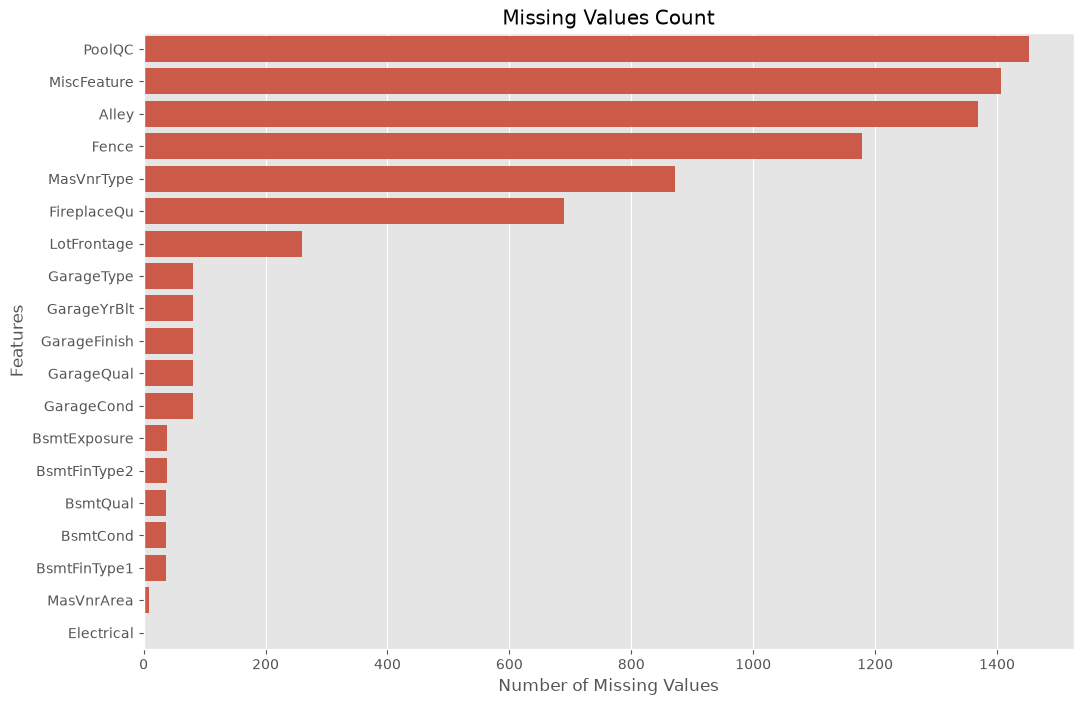

In [97]:
plt.figure(figsize=(12,8))


sns.barplot(
    x=missing_values.values,
    y=missing_values.index
)


plt.title(
    "Missing Values Count"
)


plt.xlabel(
    "Number of Missing Values"
)


plt.ylabel(
    "Features"
)


plt.savefig(
    "../images/missing_values_count.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Separate Numerical and Categorical Columns

In [73]:
numeric_columns = train_df.select_dtypes(
    include=np.number
).columns


categorical_columns = train_df.select_dtypes(
    include="object"
).columns


print(
    "Numerical Features:",
    len(numeric_columns)
)


print(
    "Categorical Features:",
    len(categorical_columns)
)

Numerical Features: 38
Categorical Features: 43


## Numerical Features List

In [74]:
numeric_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

## Categorical Features List

In [75]:
categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

## Target Variable Distribution

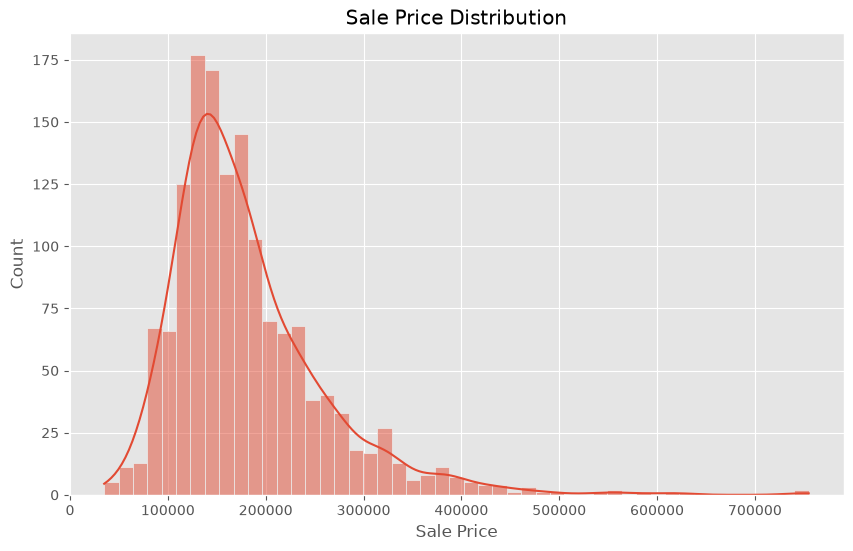

In [96]:
plt.figure(figsize=(10,6))


sns.histplot(
    train_df["SalePrice"],
    kde=True
)


plt.title(
    "Sale Price Distribution"
)


plt.xlabel(
    "Sale Price"
)


plt.savefig(
    "../images/saleprice_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Target Skewness

In [77]:
skewness = train_df["SalePrice"].skew()

print(
    "SalePrice Skewness:",
    skewness
)

SalePrice Skewness: 1.8828757597682129


## Log Transformation

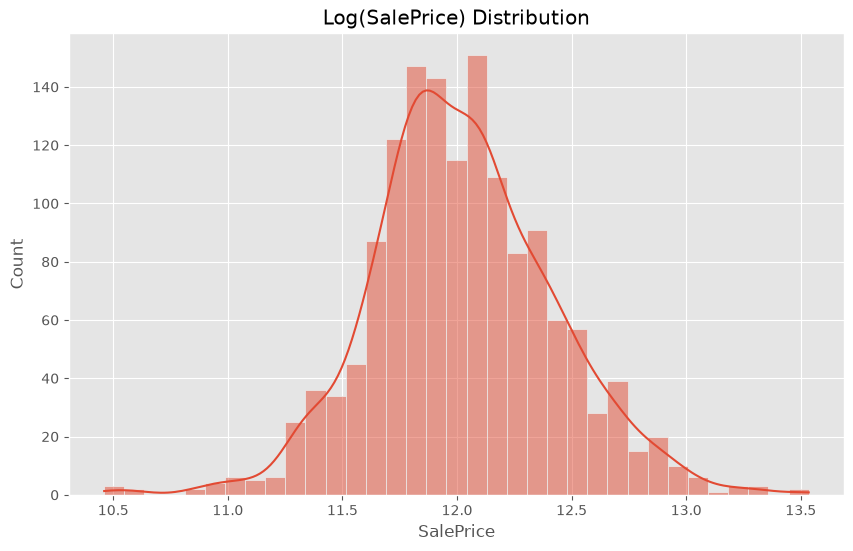

In [95]:
plt.figure(figsize=(10,6))


sns.histplot(
    np.log1p(train_df["SalePrice"]),
    kde=True
)


plt.title(
    "Log(SalePrice) Distribution"
)


plt.savefig(
    "../images/log_saleprice_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

##create preprocessing

In [80]:
from src.preprocessing import create_preprocessor


preprocessor = create_preprocessor(
    X_train
)


print("Preprocessing pipeline created")

Preprocessing pipeline created


## Import Models

In [81]:
from src.train_models import (
    get_models,
    train_models
)


models = get_models()


print(models.keys())

dict_keys(['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost'])


## Train models

In [82]:
trained_models = train_models(
    models,
    preprocessor,
    X_train,
    y_train
)


print("All models trained")

Training Linear Regression...
Training Ridge...
Training Lasso...
Training Elastic Net...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
All models trained


## Evaluate All Models

In [83]:
results = []


for name, model in trained_models.items():

    result = evaluate_model(
        model,
        X_test,
        y_test
    )

    result["Model"] = name

    results.append(result)



results_df = pd.DataFrame(results)


results_df = results_df.sort_values(
    by="RMSE"
)


results_df

,MAE,MSE,RMSE,R2 Score,MAPE,Model
7,16174.609375,6.772397e+08,26023.829080,0.911707,0.095814,XGBoost
6,16571.997186,7.322548e+08,27060.207130,0.904534,0.098875,Gradient Boosting
2,18004.300399,8.025478e+08,28329.275452,0.895370,0.111709,Lasso
5,17509.558647,8.120669e+08,28496.787082,0.894129,0.107365,Random Forest
0,18284.677599,8.688455e+08,29476.184616,0.886726,0.112829,Linear Regression
3,18811.359058,8.827007e+08,29710.279888,0.884920,0.115433,Elastic Net
1,19021.273763,9.397433e+08,30655.232540,0.877483,0.116501,Ridge
4,27668.291096,1.751675e+09,41853.012720,0.771630,0.161782,Decision Tree


## Visualize Model Performance

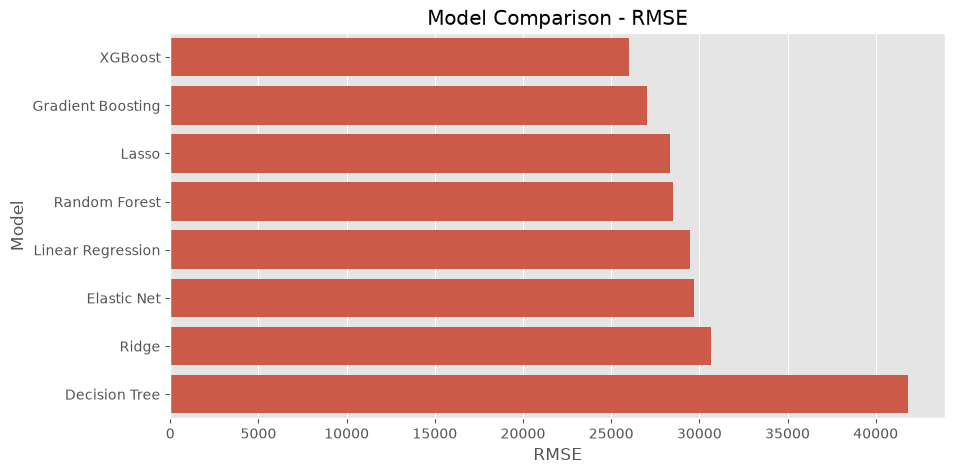

In [94]:
plt.figure(figsize=(10,5))


sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)


plt.title(
    "Model Comparison - RMSE"
)


plt.savefig(
    "../images/model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Select Best Model

In [85]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]


print(
    "Best Model:",
    best_model_name
)

Best Model: XGBoost


House-Price-Prediction/
│
├── models/

In [86]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

In [90]:
import importlib
import sys

if project_root not in sys.path:
    sys.path.append(project_root)

predict_module = importlib.import_module("src.predict")
predict_module = importlib.reload(predict_module)

save_model = predict_module.save_model
load_model = predict_module.load_model
predict = predict_module.predict

print("Prediction utilities loaded")

Prediction utilities loaded


## Confirm best model

In [91]:
print(best_model_name)

best_model

XGBoost


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

## Save model

In [92]:
model_path = "../models/best_house_price_model.pkl"


save_model(
    best_model,
    model_path
)


print("Saved:", model_path)

Saved: ../models/best_house_price_model.pkl


## Verify

In [93]:
import os

os.path.exists(
    model_path
)

True